# RetinaMNIST Diabetic Retinopathy Classification

In [1]:
!pip install medmnist torchinfo coral-pytorch

## 1. Environment setup and fix random seed

In [2]:
import random
import numpy as np
import os
import hashlib
from matplotlib import pyplot as plt
from PIL import Image
from tqdm import tqdm
import cv2
import copy

import torch
from torch import nn
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torchinfo import summary
from torch.utils.data import DataLoader, Dataset

from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, cohen_kappa_score, accuracy_score, confusion_matrix, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

from medmnist import RetinaMNIST

from coral_pytorch.layers import CoralLayer
from coral_pytorch.losses import coral_loss
from coral_pytorch.dataset import levels_from_labelbatch, proba_to_label


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ['PYTHONHASHSEED'] = str(seed)

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PREPROCESSED_DIR = "/content/preprocessed"

set_seed(SEED)

## 2. Load the dataset

In [3]:
train_dataset = RetinaMNIST(split='train', download=True, size=224)
val_dataset = RetinaMNIST(split='val', download=True, size=224)
test_dataset = RetinaMNIST(split='test', download=True, size=224)

## 3. Data exploration and preprocessing

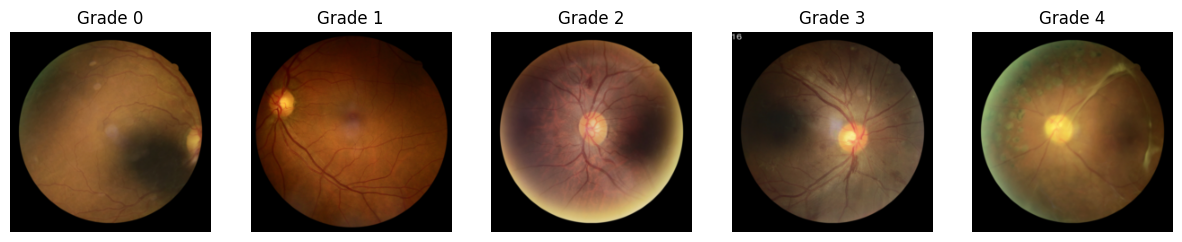

In [4]:
classes = np.unique(train_dataset.labels.flatten())

sample_images = []
for c in classes:
    labels_flat = train_dataset.labels.flatten()
    idx = np.where(labels_flat == c)[0][0]
    img_arr = np.squeeze(train_dataset.imgs[idx])
    sample_images.append(img_arr)

plt.figure(figsize=(15, 5))
for i, img_arr in enumerate(sample_images):
    plt.subplot(1, len(sample_images), i + 1)
    if img_arr.ndim == 3:
        plt.imshow(img_arr)
    else:
        plt.imshow(img_arr, cmap='gray')
    plt.title(f'Grade {int(classes[i])}')
    plt.axis('off')
plt.show()

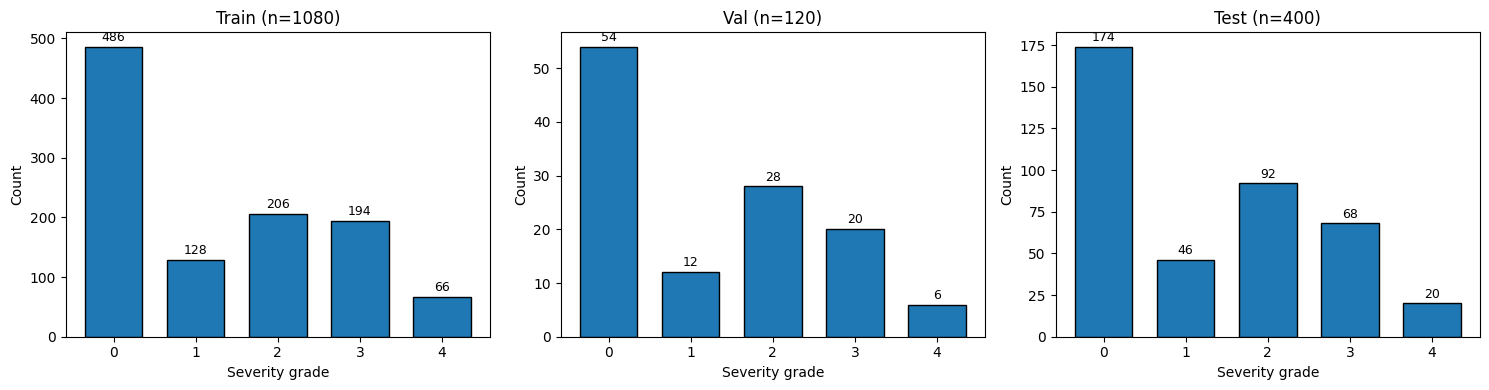

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, split_name, dataset in zip(axes,
                                    ['Train', 'Val', 'Test'],
                                    [train_dataset, val_dataset, test_dataset]):
    labels = dataset.labels.flatten()
    counts = np.bincount(labels, minlength=len(classes))
    ax.bar(classes, counts, edgecolor='black', width=0.7)
    ax.set_xticks(classes)
    ax.set_title(f'{split_name} (n={len(labels)})')
    ax.set_xlabel('Severity grade')
    ax.set_ylabel('Count')
    for cls, cnt in zip(classes, counts):
        ax.text(cls, cnt + max(counts) * 0.01, str(cnt),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Check for data leakage across splits

Even if the dataset is well-maintained, we check for duplicates across splits to ensure that there is no data leakage. We compute the MD5 hash of each image and compare them across the training, validation, and test sets. Identical images will have the same hash, so if we find any matching hashes inside and across splits, it indicates that the same image appears multiple times in the same split or in multiple splits, which could lead to data leakage and biased evaluation results.

In [6]:
def md5_hash(img_arr):
    data = img_arr.tobytes()
    return hashlib.md5(data).hexdigest()

train_hashes = [md5_hash(train_dataset.imgs[i]) for i in range(len(train_dataset))]
val_hashes = [md5_hash(val_dataset.imgs[i])   for i in range(len(val_dataset))]
test_hashes = [md5_hash(test_dataset.imgs[i])  for i in range(len(test_dataset))]

train_set = set(train_hashes)
val_set = set(val_hashes)
test_set = set(test_hashes)

print(f"\nSplit sizes:\n\tTrain={len(train_hashes)}\n\tVal={len(val_hashes)}\n\tTest={len(test_hashes)}")
print(f"Unique:\n\tTrain={len(train_set)}\n\tVal={len(val_set)}\n\tTest={len(test_set)}")
print(f"\nIntersections (potential leakage):")
print(f"\tTrain ∩ Val: {len(train_set & val_set)}")
print(f"\tTrain ∩ Test: {len(train_set & test_set)}")
print(f"\tVal ∩ Test: {len(val_set & test_set)}")

for name, h_list in [('Train', train_hashes), ('Val', val_hashes), ('Test', test_hashes)]:
    dup = len(h_list) - len(set(h_list))
    if dup > 0:
        print(f"{name} has {dup} duplicate image(s) within the split")


Split sizes:
	Train=1080
	Val=120
	Test=400
Unique:
	Train=1080
	Val=120
	Test=400

Intersections (potential leakage):
	Train ∩ Val: 0
	Train ∩ Test: 0
	Val ∩ Test: 0


## 4. Preprocessing techniques for diabetic retinopathy

Implementing techniques from the literature:
- **Ben Graham**: Gaussian unsharp masking
- **Usuyama-style**: per-channel normalization

In [7]:
def preprocess_ben_graham(img: np.ndarray, img_size: int = 224, sigma: float = 5)  -> np.ndarray:
    """
    Ben Graham-style preprocessing: resize, apply Gaussian blur, and
    add a circular mask to focus on the central region of the image.
    
    Args:
        img (np.ndarray): Input image.
        img_size (int): Size to which the image is resized (default: 224)
        sigma (float): Standard deviation for Gaussian blur (default: 5)

    Returns:
        np.ndarray: Preprocessed image.

    Reference: used in Graham, B. (2015). Kaggle Diabetic Retinopathy Detection competition.
    """
    img = cv2.resize(img, (img_size, img_size))

    img = cv2.addWeighted(
        img, 4,
        cv2.GaussianBlur(img, (0, 0), sigma), -4,
        128
    )

    mask = np.zeros_like(img)
    h, w = img.shape[:2]
    cv2.circle(mask, (w // 2, h // 2), int(min(h, w) * 0.45), (1, 1, 1), -1)
    img = img * mask + 128 * (1 - mask)

    return np.clip(img, 0, 255).astype(np.uint8)

def preprocess_usuyama(img: np.ndarray, target_size: int = 224) -> np.ndarray:
    """
    Usuyama-style preprocessing: resize, per-channel z-score normalization, and rescale to [0, 255].

    Args:
        img (np.ndarray): Input image.
        target_size (int): Size to which the image is resized (default: 224)

    Returns:
        np.ndarray: Preprocessed image.

    Reference: used in Minarno et al., JOIV 2022
    """
    resized = cv2.resize(img, (target_size, target_size)).astype(np.float32)

    for ch in range(3):
        ch_data = resized[:, :, ch]
        m, s = ch_data.mean(), ch_data.std()
        if s > 0:
            resized[:, :, ch] = (ch_data - m) / s
        else:
            resized[:, :, ch] = ch_data - m

    resized = resized - resized.min()
    resized = (resized / (resized.max() + 1e-8) * 255).astype(np.uint8)

    # TODO: clahe(?)

    return resized

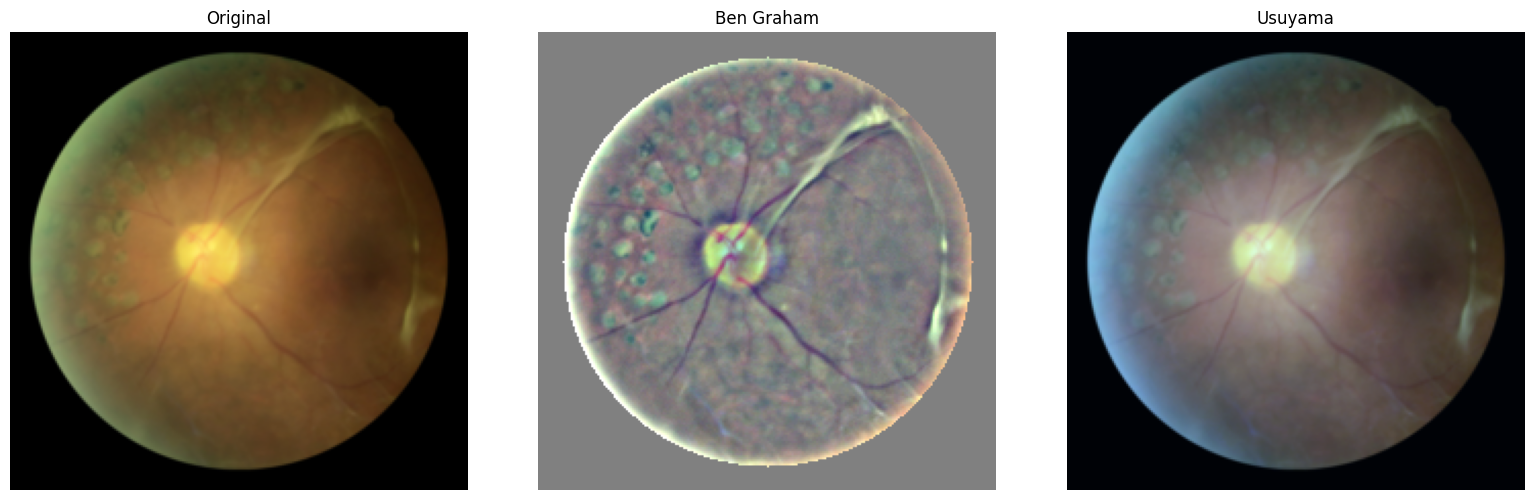

In [8]:
viz_class = 4

labels_flat = train_dataset.labels.flatten()
idx_sample = np.where(labels_flat == viz_class)[0][0]
sample = np.squeeze(train_dataset.imgs[idx_sample]).astype(np.uint8)

original = cv2.resize(sample, (224, 224))
bg = preprocess_ben_graham(sample, sigma=5)
usuyama = preprocess_usuyama(sample)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ['Original', 'Ben Graham', 'Usuyama']
for ax, img, title in zip(axes, [original, bg, usuyama], titles):
    ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [9]:
splits = [
    ("train", train_dataset),
    ("val",   val_dataset),
    ("test",  test_dataset),
]

for split_name, dataset in splits:
    labels_flat = dataset.labels.flatten()
    class_counts: dict[int, int] = {}
    for i in tqdm(range(len(dataset)), desc=split_name):
        label = int(labels_flat[i])
        class_dir = os.path.join(PREPROCESSED_DIR, split_name, str(label))
        os.makedirs(class_dir, exist_ok=True)

        img = np.squeeze(dataset.imgs[i]).astype(np.uint8)
        proc = preprocess_ben_graham(img)
        # proc = preprocess_usuyama(img)
        # proc = img

        class_counts[label] = class_counts.get(label, 0) + 1
        fname = f"{class_counts[label]:05d}.png"
        Image.fromarray(proc).save(os.path.join(class_dir, fname))

print(f"Images saved under {PREPROCESSED_DIR}/")

test: 100%|██████████| 400/400 [00:10<00:00, 38.96it/s]

Images saved under /content/preprocessed/


In [10]:
def load_preprocessed(split_name: str) -> tuple[np.ndarray, np.ndarray]:
    """
    Load saved preprocessed images and labels.
    
    Args:
        split_name (str): Name of the dataset split ('train', 'val', or 'test').
    Returns:
        Tuple[np.ndarray, np.ndarray]: A tuple containing:
            - imgs: A numpy array of shape (N, H, W, C) containing the preprocessed images.
            - labels: A numpy array of shape (N,) containing the corresponding labels for the images.
    """
    split_dir = os.path.join(PREPROCESSED_DIR, split_name)
    imgs, labels = [], []
    class_dirs = sorted(os.listdir(split_dir))
    for cls_dir in class_dirs:
        cls = int(cls_dir)
        img_folder = os.path.join(split_dir, cls_dir)
        for fname in sorted(os.listdir(img_folder), key=lambda x: int(x.split(".")[0])):
            fpath = os.path.join(img_folder, fname)
            img = cv2.imread(fpath)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            imgs.append(img)
            labels.append(cls)
    return np.stack(imgs), np.array(labels)

train_proc_imgs, train_proc_labels = load_preprocessed("train")
val_proc_imgs, val_proc_labels = load_preprocessed("val")
test_proc_imgs, test_proc_labels = load_preprocessed("test")

print(f"Train: {train_proc_imgs.shape} | labels={train_proc_labels.shape}")
print(f"Val: {val_proc_imgs.shape} | labels={val_proc_labels.shape}")
print(f"Test: {test_proc_imgs.shape} | labels={test_proc_labels.shape}")

Train: (1080, 224, 224, 3) | labels=(1080,)
Val: (120, 224, 224, 3) | labels=(120,)
Test: (400, 224, 224, 3) | labels=(400,)


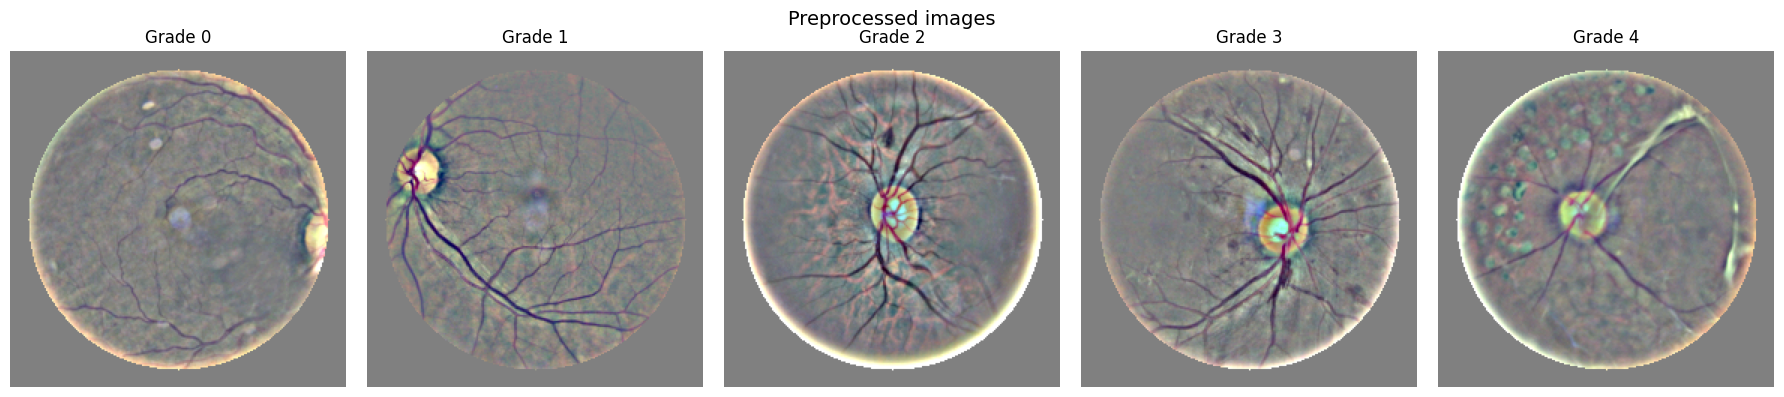

In [11]:
classes = np.unique(train_proc_labels.flatten())
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for idx, cls in enumerate(classes):
    labels_flat = train_proc_labels.flatten()
    sample_idx = np.where(labels_flat == cls)[0][0]
    sample = np.squeeze(train_proc_imgs[sample_idx]).astype(np.uint8)

    axes[idx].imshow(sample)
    axes[idx].set_title(f"Grade {int(cls)}", fontsize=12)
    axes[idx].axis("off")

fig.suptitle("Preprocessed images", fontsize=14)
plt.tight_layout()
plt.show()

Per-channel statistics (preprocessed training set):
 Channel     Mean      Std    Min    Max
       R   130.81    19.77      0    255
       G   129.74    19.15      0    255
       B   129.03    11.60      0    255

Mean (normalized): [0.31081352 0.31081352 0.31081352]
Std  (normalized): [0.1828112  0.1761836  0.15619852]


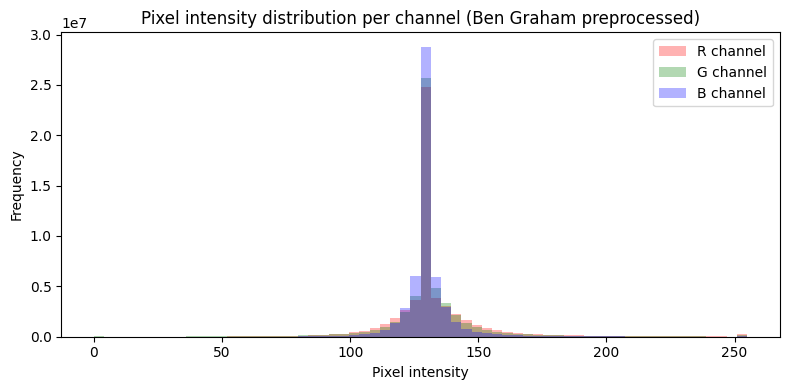

In [12]:
pixels = train_proc_imgs.reshape(-1, 3).astype(np.float32)

print("Per-channel statistics (preprocessed training set):")
print(f"{'Channel':>8} {'Mean':>8} {'Std':>8} {'Min':>6} {'Max':>6}")
for ch, name in enumerate(['R', 'G', 'B']):
    data = pixels[:, ch]
    print(f"{name:>8} {data.mean():>8.2f} {data.std():>8.2f} "
          f"{int(data.min()):>6} {int(data.max()):>6}")

mean = pixels.mean(axis=0) / 255.0
std = pixels.std(axis=0) / 255.0

print(f"\nMean (normalized): {mean}")
print(f"Std  (normalized): {std}")

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['red', 'green', 'blue']
for ch, color in enumerate(colors):
    ax.hist(pixels[:, ch], bins=64, color=color, alpha=0.3,
            label=f'{["R","G","B"][ch]} channel')
ax.set_xlabel('Pixel intensity')
ax.set_ylabel('Frequency')
ax.set_title('Pixel intensity distribution per channel (Ben Graham preprocessed)')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Data augmentation

To avoid the alteration of features that are clinically important for diagnosis, we apply only simple augmentations, such as **random horizontal and vertical flips**, and **random rotations**. We avoid augmentations that could change the appearance of lesions or other important features, involving colors, brightness, or contrast. We also avoid cropping or resizing that could remove important parts of the retina.

In [13]:
train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomAffine(degrees=90, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.0, hue=0.0),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=mean, std=std),
])

eval_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=mean, std=std),
])

train_data = ImageFolder(root=os.path.join(PREPROCESSED_DIR, "train"), transform=train_transforms)
val_data   = ImageFolder(root=os.path.join(PREPROCESSED_DIR, "val"),   transform=eval_transforms)
test_data  = ImageFolder(root=os.path.join(PREPROCESSED_DIR, "test"),  transform=eval_transforms)

print(f"Train: {len(train_data)} samples, classes={train_data.classes}")
print(f"Val:   {len(val_data)} samples,   classes={val_data.classes}")
print(f"Test:  {len(test_data)} samples,  classes={test_data.classes}")

Train: 1080 samples, classes=['0', '1', '2', '3', '4']
Val:   120 samples,   classes=['0', '1', '2', '3', '4']
Test:  400 samples,  classes=['0', '1', '2', '3', '4']


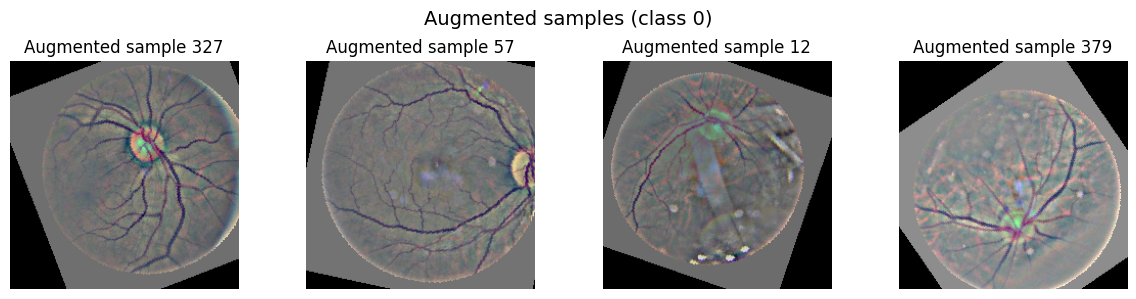

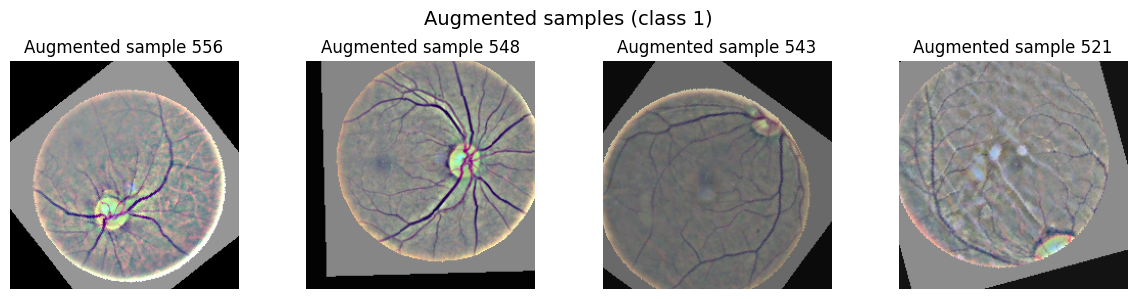

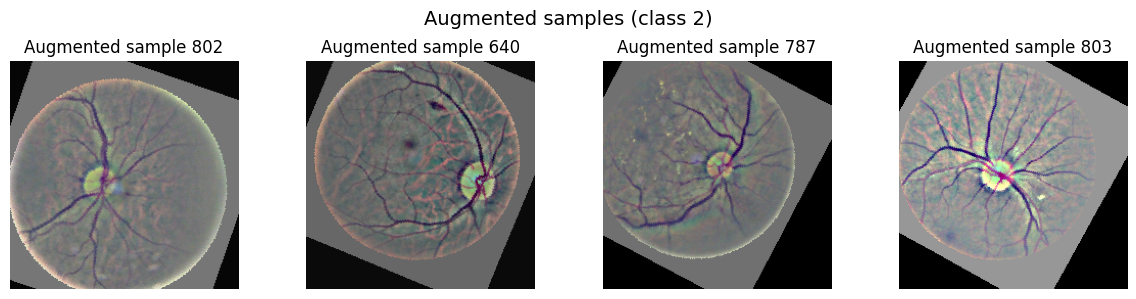

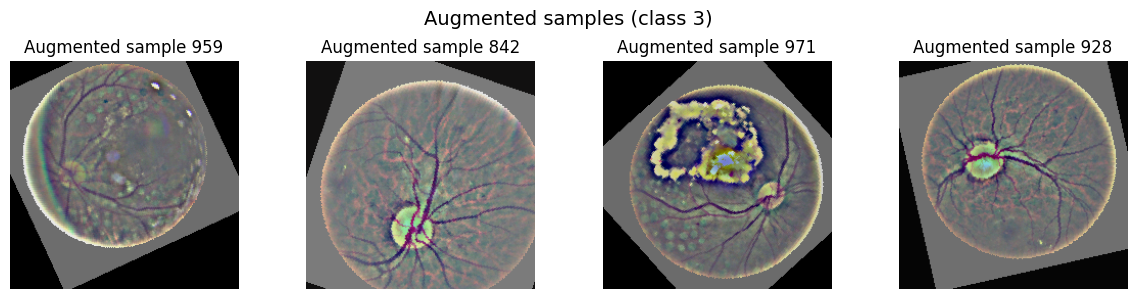

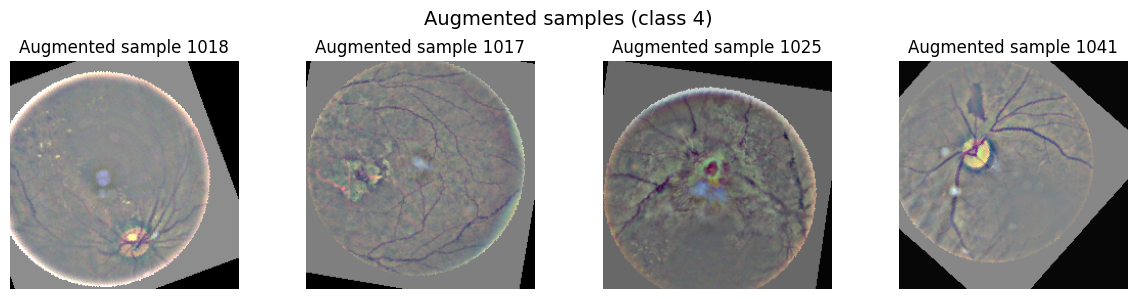

In [14]:

def plot_augmented_samples(dataset, class_idx, num_samples=4) -> None:
    """
    Plot augmented samples from the dataset for a specific class.

    Args:
        dataset (ImageFolder): The dataset containing the images.
        class_idx (int): The index of the class to visualize.
        num_samples (int): Number of augmented samples to display.
    """
    # Filter indices for the specified class
    class_indices = [i for i, (_, label) in enumerate(dataset.samples) if label == class_idx]
    
    # Randomly select indices for augmentation
    selected_indices = random.sample(class_indices, num_samples)
    
    plt.figure(figsize=(12, 3))
    
    for i, idx in enumerate(selected_indices):
        img, _ = dataset[idx]
        img = img.permute(1, 2, 0).numpy()  # Convert from CxHxW to HxWxC
        img = (img * std + mean) * 255.0  # Denormalize
        img = np.clip(img, 0, 255).astype(np.uint8)
        
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f'Augmented sample {selected_indices[i]}')
        plt.axis('off')
    
    plt.suptitle(f'Augmented samples (class {class_idx})', fontsize=14)
    plt.tight_layout()
    plt.show()

# Example usage: Plot augmented samples for class 4
plot_augmented_samples(train_data, class_idx=0, num_samples=4)
plot_augmented_samples(train_data, class_idx=1, num_samples=4)
plot_augmented_samples(train_data, class_idx=2, num_samples=4)
plot_augmented_samples(train_data, class_idx=3, num_samples=4)
plot_augmented_samples(train_data, class_idx=4, num_samples=4)

## 6. Model architecture

Micro SE Net?

first block:

conv2d 3x3 16 or 32 filters, batch norm relu maxpool

second and third(?) blocks:
conv2d 3x3 32 or 64 filters, batch norm, se block, relu maxpool

adaptive average pooling, flatten, dense 5 units softmax

In [15]:
from torch.nn import functional as F

class SEBlock(nn.Module):
    """Squeeze-and-Excitation block: GAP + FC reduce + ReLU + FC expand + sigmoid."""
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        reduced = max(channels // reduction, 1)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, reduced, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(reduced, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c, _, _ = x.shape
        scale = self.pool(x).view(b, c)
        scale = self.fc(scale).view(b, c, 1, 1)
        return x * scale


class MicroSENet(nn.Module):
    """
    CNN with optional SE blocks for 5-class ordinal DR grading (224x224 inputs).
    Supports CE and CORAL heads, DLA early fusion, and ablation flags.
    """
    def __init__(
        self,
        num_classes: int = 5,
        se_reduction: int = 16,
        use_coral: bool = False,
        use_dla: bool = False,
        use_se: bool = True,
        use_compression: bool = True,
    ):
        super().__init__()
        self.num_classes = num_classes
        self.use_coral = use_coral
        self.use_dla = use_dla

        def conv_block(in_ch, out_ch):
            layers = [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
            if use_se:
                layers.append(SEBlock(out_ch, se_reduction))
            layers += [nn.MaxPool2d(2), nn.Dropout2d(p=0.1)]
            return nn.Sequential(*layers)

        self.block1 = conv_block(3, 32)
        self.block2 = conv_block(32, 64)
        self.block3 = conv_block(64, 128)
        self.block4 = conv_block(128, 256)
        self.block5 = conv_block(256, 512)

        features_in = 512 + 64 if use_dla else 512

        if use_coral:
            if use_compression:
                self.head = nn.Sequential(
                    nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                    nn.Linear(features_in, 256), nn.ReLU(inplace=True), nn.Dropout(p=0.5),
                    CoralLayer(256, num_classes),
                )
            else:
                self.head = nn.Sequential(
                    nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                    CoralLayer(features_in, num_classes),
                )
        else:
            if use_compression:
                self.head = nn.Sequential(
                    nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                    nn.Linear(features_in, 256), nn.ReLU(inplace=True), nn.Dropout(p=0.5),
                    nn.Linear(256, num_classes),
                )
            else:
                self.head = nn.Sequential(
                    nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                    nn.Linear(features_in, num_classes),
                )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if not self.use_dla:
            x = self.block1(x)
            x = self.block2(x)
            x = self.block3(x)
            x = self.block4(x)
            x = self.block5(x)
            return self.head(x)

        # DLA: concatenate early (block2, 56x56 -> pooled to 7x7) with deep (block5, 7x7) features
        x = self.block1(x)
        out2 = self.block2(x)
        x = self.block3(out2)
        x = self.block4(x)
        out5 = self.block5(x)
        out2_aligned = F.adaptive_avg_pool2d(out2, out5.shape[2:])
        fused = torch.cat([out5, out2_aligned], dim=1)
        return self.head(fused)

In [16]:
model = MicroSENet(num_classes=5, use_dla=True).to(DEVICE)
summary(model, input_size=(1, 3, 224, 224), device=DEVICE)

Layer (type:depth-idx)                   Output Shape              Param #
MicroSENet                               [1, 5]                    --
├─Sequential: 1-1                        [1, 32, 112, 112]         --
│    └─Conv2d: 2-1                       [1, 32, 224, 224]         864
│    └─BatchNorm2d: 2-2                  [1, 32, 224, 224]         64
│    └─ReLU: 2-3                         [1, 32, 224, 224]         --
│    └─SEBlock: 2-4                      [1, 32, 224, 224]         --
│    │    └─AdaptiveAvgPool2d: 3-1       [1, 32, 1, 1]             --
│    │    └─Sequential: 3-2              [1, 32]                   128
│    └─MaxPool2d: 2-5                    [1, 32, 112, 112]         --
│    └─Dropout2d: 2-6                    [1, 32, 112, 112]         --
├─Sequential: 1-2                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-7                       [1, 64, 112, 112]         18,432
│    └─BatchNorm2d: 2-8                  [1, 64, 112, 112]         128
│    └─R

In [17]:
model_coral = MicroSENet(num_classes=5, use_coral=True, use_dla=False).to(DEVICE)
summary(model_coral, input_size=(1, 3, 224, 224), device=DEVICE)

Layer (type:depth-idx)                   Output Shape              Param #
MicroSENet                               [1, 4]                    --
├─Sequential: 1-1                        [1, 32, 112, 112]         --
│    └─Conv2d: 2-1                       [1, 32, 224, 224]         864
│    └─BatchNorm2d: 2-2                  [1, 32, 224, 224]         64
│    └─ReLU: 2-3                         [1, 32, 224, 224]         --
│    └─SEBlock: 2-4                      [1, 32, 224, 224]         --
│    │    └─AdaptiveAvgPool2d: 3-1       [1, 32, 1, 1]             --
│    │    └─Sequential: 3-2              [1, 32]                   128
│    └─MaxPool2d: 2-5                    [1, 32, 112, 112]         --
│    └─Dropout2d: 2-6                    [1, 32, 112, 112]         --
├─Sequential: 1-2                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-7                       [1, 64, 112, 112]         18,432
│    └─BatchNorm2d: 2-8                  [1, 64, 112, 112]         128
│    └─R

## 7. Model training

Pay attention to weight initialization w.r.t. class imbalance.

In [18]:
def worker_init_fn(worker_id: int) -> None:
    """
    Seed each DataLoader worker deterministically based on its ID.
    
    Args:
        worker_id (int): The ID of the DataLoader worker.
    """
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)
    torch.manual_seed(SEED + worker_id)

# Set CUDA workspace config for deterministic cuBLAS operations in CUDA 12+
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

torch.use_deterministic_algorithms(True, warn_only=True)

GEN = torch.Generator()
GEN.manual_seed(SEED)

class FolderDataset(Dataset):
    """pytorch Dataset for fold splits: loads images by path with given transform."""
    def __init__(self, paths, targets, transform):
        self.paths = paths
        self.targets = targets
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        target = self.targets[idx]
        if self.transform:
            img = self.transform(img)
        return img, target


all_paths = [p for p, _ in train_data.imgs]
all_targets = np.array(train_data.targets)

### Cross-entropy loss with class weights

In [ ]:
# Reset seeds for reproducibility on re-run
set_seed(SEED)
GEN.manual_seed(SEED)

N_FOLDS = 5
EPOCHS = 50
BATCH_SIZE = 32

classes = np.unique(all_targets)
class_weights = compute_class_weight('balanced', classes=classes, y=all_targets)
w = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print("Class weights:", dict(zip(classes.tolist(), np.round(class_weights, 3))))

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(all_targets)), all_targets), 1):
    print(f"\nFold {fold}/{N_FOLDS}")

    train_fold = FolderDataset([all_paths[i] for i in train_idx], all_targets[train_idx], train_transforms)
    val_fold   = FolderDataset([all_paths[i] for i in val_idx],   all_targets[val_idx],   eval_transforms)

    train_loader = DataLoader(train_fold, BATCH_SIZE, shuffle=True,
                              worker_init_fn=worker_init_fn, num_workers=2, generator=GEN)
    val_loader   = DataLoader(val_fold,   BATCH_SIZE, shuffle=False,
                              worker_init_fn=worker_init_fn, num_workers=2, generator=GEN)

    model = MicroSENet(num_classes=5, use_dla=True).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=w)
    val_criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

    best_auc, best_state, stale_epochs = 0.0, None, 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0
        all_preds, all_labels, all_probs = [], [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                logits = model(x)
                val_loss += val_criterion(logits, y).item()
                all_preds.extend(logits.argmax(dim=1).cpu().numpy())
                all_labels.extend(y.cpu().numpy())
                all_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
        val_loss /= len(val_loader)
        all_probs = np.concatenate(all_probs)

        acc = accuracy_score(all_labels, all_preds)
        qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
        f1 = f1_score(all_labels, all_preds, average='macro')

        if auc > best_auc:
            best_auc = auc
            best_state = copy.deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1

        scheduler.step()

        if epoch == 1 or epoch % 5 == 0:
            lr_now = optimizer.param_groups[0]['lr']
            print(f"  Epoch {epoch:2d}/{EPOCHS} | LR: {lr_now:.2e} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | Acc: {acc:.4f} | QWK: {qwk:.4f} | AUC: {auc:.4f}")

        if stale_epochs >= 10:
            print(f"  Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_state)

    model.eval()
    best_preds, best_labels, best_probs = [], [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            best_preds.extend(logits.argmax(dim=1).cpu().numpy())
            best_labels.extend(y.cpu().numpy())
            best_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
    best_probs = np.concatenate(best_probs)
    best_acc_actual = accuracy_score(best_labels, best_preds)
    best_qwk = cohen_kappa_score(best_labels, best_preds, weights='quadratic')
    best_auc_actual = roc_auc_score(best_labels, best_probs, multi_class='ovr', average='macro')

    fold_results.append(best_acc_actual)
    print(f"  Fold {fold}: accuracy={best_acc_actual:.4f} qwk={best_qwk:.4f} auc={best_auc_actual:.4f}")

print(f"\nResults (CE, {N_FOLDS}-fold CV):")
print(f"  Accuracy: {np.mean(fold_results):.4f} +/- {np.std(fold_results):.4f}")

Class weights: {0: np.float64(0.444), 1: np.float64(1.688), 2: np.float64(1.049), 3: np.float64(1.113), 4: np.float64(3.273)}

Fold 1/5
  Epoch  1/50 | LR: 3.00e-04 | Train loss: 1.6155 | Val loss: 1.4960 | Acc: 0.4537 | QWK: 0.0000 | AUC: 0.6147
  Epoch  5/50 | LR: 2.93e-04 | Train loss: 1.5466 | Val loss: 1.3949 | Acc: 0.4769 | QWK: 0.4322 | AUC: 0.7212
  Epoch 10/50 | LR: 2.71e-04 | Train loss: 1.4612 | Val loss: 1.2778 | Acc: 0.4954 | QWK: 0.5710 | AUC: 0.7634
  Epoch 15/50 | LR: 2.38e-04 | Train loss: 1.3912 | Val loss: 1.4916 | Acc: 0.3889 | QWK: 0.5217 | AUC: 0.7195
  Epoch 20/50 | LR: 1.97e-04 | Train loss: 1.3296 | Val loss: 1.1666 | Acc: 0.5231 | QWK: 0.6097 | AUC: 0.7925
  Epoch 25/50 | LR: 1.50e-04 | Train loss: 1.3104 | Val loss: 1.1787 | Acc: 0.5000 | QWK: 0.6480 | AUC: 0.7945
  Epoch 30/50 | LR: 1.04e-04 | Train loss: 1.2928 | Val loss: 1.1725 | Acc: 0.4676 | QWK: 0.6866 | AUC: 0.8106
  Epoch 35/50 | LR: 6.26e-05 | Train loss: 1.2949 | Val loss: 1.1418 | Acc: 0.5185 | QW

Training final CE model on full training set
Class weights: {0: np.float64(0.444), 1: np.float64(1.688), 2: np.float64(1.049), 3: np.float64(1.113), 4: np.float64(3.273)}


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  Epoch  1/50 | LR: 3.00e-04 | Train loss: 1.6139 | Val loss: 1.4933 | Acc: 0.4500 | QWK: 0.0000 | AUC: 0.6491


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._e

  Epoch  5/50 | LR: 2.93e-04 | Train loss: 1.5058 | Val loss: 1.4134 | Acc: 0.4417 | QWK: 0.5856 | AUC: 0.7344


...

  Epoch 35/50 | LR: 6.26e-05 | Train loss: 1.2480 | Val loss: 1.2264 | Acc: 0.5333 | QWK: 0.6582 | AUC: 0.7976


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._e

  Epoch 40/50 | LR: 2.96e-05 | Train loss: 1.2312 | Val loss: 1.1887 | Acc: 0.5250 | QWK: 0.6890 | AUC: 0.8045


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  Early stopping at epoch 41

Validation set results:
  Macro F1:  0.4474
  QWK:       0.6873
  Accuracy:  0.5167
  AUC:       0.8090

Per-class metrics:
  Grade 0: precision=0.675 recall=0.667 F1=0.671
  Grade 1: precision=0.295 recall=0.500 F1=0.371
  Grade 2: precision=0.750 recall=0.250 F1=0.375
  Grade 3: precision=0.565 recall=0.450 F1=0.501
  Grade 4: precision=0.560 recall=0.667 F1=0.609


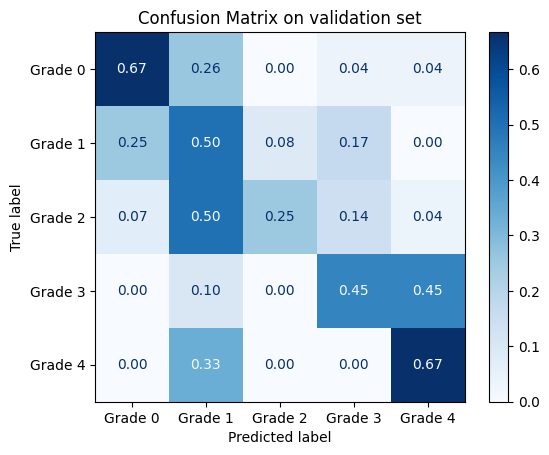

In [20]:
print("Training final CE model on full training set")

# Reset seeds for reproducibility on re-run
set_seed(SEED)
GEN.manual_seed(SEED)

EPOCHS = 50
BATCH_SIZE = 32

classes = np.unique(all_targets)
class_weights = compute_class_weight('balanced', classes=classes, y=all_targets)
w = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print("Class weights:", dict(zip(classes.tolist(), np.round(class_weights, 3))))

final_loader = DataLoader(
    FolderDataset(all_paths, all_targets, train_transforms),
    batch_size=BATCH_SIZE, shuffle=True,
    worker_init_fn=worker_init_fn, num_workers=2,
    generator=GEN
)
val_loader  = DataLoader(val_data,  batch_size=BATCH_SIZE, shuffle=False,
                         worker_init_fn=worker_init_fn, num_workers=2, generator=GEN)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False,
                         worker_init_fn=worker_init_fn, num_workers=2, generator=GEN)

model_final = MicroSENet(num_classes=5, use_dla=True).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=w)
val_criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_final.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_auc, best_state, stale_epochs = 0.0, None, 0

for epoch in range(1, EPOCHS + 1):
    model_final.train()
    train_loss = 0.0
    for x, y in final_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model_final(x), y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(final_loader)

    model_final.eval()
    val_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model_final(x)
            val_loss += val_criterion(logits, y).item()
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
    val_loss /= len(val_loader)
    all_probs = np.concatenate(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')

    if auc > best_auc:
        best_auc = auc
        best_state = copy.deepcopy(model_final.state_dict())
        stale_epochs = 0
    else:
        stale_epochs += 1

    scheduler.step()

    if epoch == 1 or epoch % 5 == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f"  Epoch {epoch:2d}/{EPOCHS} | LR: {lr_now:.2e} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | Acc: {acc:.4f} | QWK: {qwk:.4f} | AUC: {auc:.4f}")

    if stale_epochs >= 10:
        print(f"  Early stopping at epoch {epoch}")
        break

model_final.load_state_dict(best_state)
model_final.eval()

val_preds, val_labels, val_probs = [], [], []
with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model_final(x)
        val_preds.extend(logits.argmax(dim=1).cpu().numpy())
        val_labels.extend(y.cpu().numpy())
        val_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
val_probs = np.concatenate(val_probs)

print(f"\nValidation set results:")
print(f"  Macro F1:  {f1_score(val_labels, val_preds, average='macro'):.4f}")
print(f"  QWK:       {cohen_kappa_score(val_labels, val_preds, weights='quadratic'):.4f}")
print(f"  Accuracy:  {accuracy_score(val_labels, val_preds):.4f}")
print(f"  AUC:       {roc_auc_score(val_labels, val_probs, multi_class='ovr', average='macro'):.4f}")

cm = confusion_matrix(val_labels, val_preds, normalize='true')

print(f"\nPer-class metrics:")
for cls in range(5):
    recall = cm[cls, cls] / cm[cls].sum() if cm[cls].sum() > 0 else 0.0
    prec   = cm[:, cls][cls] / cm[:, cls].sum() if cm[:, cls].sum() > 0 else 0.0
    f1_c   = 2 * prec * recall / (prec + recall + 1e-8)
    print(f"  Grade {cls}: precision={prec:.3f} recall={recall:.3f} F1={f1_c:.3f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4'])
disp.plot(cmap=plt.cm.Blues, values_format='.2f')
plt.title("Confusion Matrix on validation set")
plt.show()

In [ ]:
test_preds, test_labels, test_probs = [], [], []
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model_final(x)
        test_preds.extend(logits.argmax(dim=1).cpu().numpy())
        test_labels.extend(y.cpu().numpy())
        test_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
test_probs = np.concatenate(test_probs)

print(f"Test set results:")
print(f"  Macro F1:  {f1_score(test_labels, test_preds, average='macro'):.4f}")
print(f"  QWK:       {cohen_kappa_score(test_labels, test_preds, weights='quadratic'):.4f}")
print(f"  Accuracy:  {accuracy_score(test_labels, test_preds):.4f}")
print(f"  AUC:       {roc_auc_score(test_labels, test_probs, multi_class='ovr', average='macro'):.4f}")

cm = confusion_matrix(test_labels, test_preds, normalize='true')

print(f"\nPer-class metrics:")
for cls in range(5):
    recall = cm[cls, cls] / cm[cls].sum() if cm[cls].sum() > 0 else 0.0
    prec   = cm[:, cls][cls] / cm[:, cls].sum() if cm[:, cls].sum() > 0 else 0.0
    f1_c   = 2 * prec * recall / (prec + recall + 1e-8)
    print(f"  Grade {cls}: precision={prec:.3f} recall={recall:.3f} F1={f1_c:.3f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4'])
disp.plot(cmap=plt.cm.Blues, values_format='.2f')
plt.title("Confusion Matrix on test set")
plt.show()

In [22]:
# Reset seeds for reproducibility on re-run
set_seed(SEED)
GEN.manual_seed(SEED)

print("CORAL loss model - Nested 5-fold CV")

N_FOLDS = 5
EPOCHS = 50
BATCH_SIZE = 32

# CORAL importance weights (Cao et al. 2019, Eq.7)
N_CORAL = len(all_targets)
class_counts_coral = np.bincount(all_targets, minlength=5)
cum_pos_coral = np.cumsum(class_counts_coral[::-1])[::-1][1:]  # S_k for k=0..3
M_coral = np.maximum(cum_pos_coral, N_CORAL - cum_pos_coral)
sqrt_M_coral = np.sqrt(M_coral)
coral_importance = torch.tensor(
    sqrt_M_coral / sqrt_M_coral.max(), dtype=torch.float32, device=DEVICE
)
print(f"CORAL importance weights: {coral_importance.cpu().numpy()}")

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(all_targets)), all_targets), 1):
    print(f"\nFold {fold}/{N_FOLDS}")

    train_fold = FolderDataset([all_paths[i] for i in train_idx], all_targets[train_idx], train_transforms)
    val_fold   = FolderDataset([all_paths[i] for i in val_idx],   all_targets[val_idx],   eval_transforms)

    train_loader = DataLoader(train_fold, BATCH_SIZE, shuffle=True,
                              worker_init_fn=worker_init_fn, num_workers=2, generator=GEN)
    val_loader   = DataLoader(val_fold,   BATCH_SIZE, shuffle=False,
                              worker_init_fn=worker_init_fn, num_workers=2, generator=GEN)

    model = MicroSENet(num_classes=5, use_coral=True).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

    best_auc, best_state, stale_epochs = 0.0, None, 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            levels = levels_from_labelbatch(y, num_classes=model.num_classes).to(DEVICE)
            optimizer.zero_grad()
            logits = model(x)
            loss = coral_loss(logits, levels, importance_weights=coral_importance)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0
        all_preds, all_labels, all_probs = [], [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                logits = model(x)
                levels = levels_from_labelbatch(y, num_classes=model.num_classes).to(DEVICE)
                val_loss += coral_loss(logits, levels, importance_weights=coral_importance).item()

                probas = torch.sigmoid(logits)
                preds = proba_to_label(probas)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y.cpu().numpy())

                # Convert (N, K-1) sigmoid probs -> (N, K) per-class probs for AUC
                class_probs = torch.cat([
                    1 - probas[:, :1],
                    probas[:, :-1] - probas[:, 1:],
                    probas[:, -1:],
                ], dim=1)
                all_probs.append(class_probs.cpu().numpy())
        val_loss /= len(val_loader)
        all_probs = np.concatenate(all_probs)

        acc = accuracy_score(all_labels, all_preds)
        qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
        f1 = f1_score(all_labels, all_preds, average='macro')

        if auc > best_auc:
            best_auc = auc
            best_state = copy.deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1

        scheduler.step()

        if epoch == 1 or epoch % 5 == 0:
            lr_now = optimizer.param_groups[0]['lr']
            print(f"  Epoch {epoch:2d}/{EPOCHS} | LR: {lr_now:.2e} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | Acc: {acc:.4f} | QWK: {qwk:.4f} | AUC: {auc:.4f}")

        if stale_epochs >= 10:
            print(f"  Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    model.eval()
    best_preds, best_labels, best_probs = [], [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            probas = torch.sigmoid(logits)
            best_preds.extend(proba_to_label(probas).cpu().numpy())
            best_labels.extend(y.cpu().numpy())

            class_probs = torch.cat([
                1 - probas[:, :1],
                probas[:, :-1] - probas[:, 1:],
                probas[:, -1:],
            ], dim=1)
            best_probs.append(class_probs.cpu().numpy())
    best_probs = np.concatenate(best_probs)
    best_acc_actual = accuracy_score(best_labels, best_preds)
    best_qwk = cohen_kappa_score(best_labels, best_preds, weights='quadratic')
    best_auc_actual = roc_auc_score(best_labels, best_probs, multi_class='ovr', average='macro')

    fold_results.append(best_acc_actual)
    print(f"  Fold {fold}: accuracy={best_acc_actual:.4f} qwk={best_qwk:.4f} auc={best_auc_actual:.4f}")

print(f"\nResults (CORAL, {N_FOLDS}-fold CV):")
print(f"  Accuracy: {np.mean(fold_results):.4f} +/- {np.std(fold_results):.4f}")

CORAL loss model - Nested 5-fold CV
CORAL importance weights: [0.76537496 0.77815336 0.8992655  1.        ]

Fold 1/5
  Epoch  1/50 | LR: 3.00e-04 | Train loss: 2.0684 | Val loss: 2.0135 | Acc: 0.4537 | QWK: 0.0000 | AUC: 0.6702
  Epoch  5/50 | LR: 2.93e-04 | Train loss: 1.7984 | Val loss: 1.7640 | Acc: 0.4676 | QWK: 0.1906 | AUC: 0.6979
  Epoch 10/50 | LR: 2.71e-04 | Train loss: 1.6655 | Val loss: 1.7373 | Acc: 0.4722 | QWK: 0.2742 | AUC: 0.7302
  Epoch 15/50 | LR: 2.38e-04 | Train loss: 1.6453 | Val loss: 1.5188 | Acc: 0.5093 | QWK: 0.6659 | AUC: 0.7518
  Epoch 20/50 | LR: 1.97e-04 | Train loss: 1.5454 | Val loss: 1.4784 | Acc: 0.5463 | QWK: 0.5939 | AUC: 0.7428
  Epoch 25/50 | LR: 1.50e-04 | Train loss: 1.5291 | Val loss: 1.4489 | Acc: 0.5139 | QWK: 0.5603 | AUC: 0.7623
  Epoch 30/50 | LR: 1.04e-04 | Train loss: 1.5128 | Val loss: 1.4216 | Acc: 0.5417 | QWK: 0.5951 | AUC: 0.7598
  Epoch 35/50 | LR: 6.26e-05 | Train loss: 1.5145 | Val loss: 1.4038 | Acc: 0.5370 | QWK: 0.6214 | AUC: 0

Training final CORAL model on full training set
CORAL importance weights: [0.76537496 0.77815336 0.8992655  1.        ]
  Epoch  1/50 | LR: 3.00e-04 | Train loss: 2.0287 | Val loss: 2.0207 | Acc: 0.4500 | QWK: 0.0000 | AUC: 0.6434
  Epoch  5/50 | LR: 2.93e-04 | Train loss: 1.7308 | Val loss: 1.6976 | Acc: 0.4417 | QWK: 0.2782 | AUC: 0.6913
  Epoch 10/50 | LR: 2.71e-04 | Train loss: 1.6199 | Val loss: 1.5932 | Acc: 0.4833 | QWK: 0.4221 | AUC: 0.7212
  Epoch 15/50 | LR: 2.38e-04 | Train loss: 1.5860 | Val loss: 1.5577 | Acc: 0.5167 | QWK: 0.6298 | AUC: 0.7451
  Epoch 20/50 | LR: 1.97e-04 | Train loss: 1.5222 | Val loss: 1.5092 | Acc: 0.5417 | QWK: 0.6468 | AUC: 0.7570
  Epoch 25/50 | LR: 1.50e-04 | Train loss: 1.4829 | Val loss: 1.4658 | Acc: 0.5083 | QWK: 0.5854 | AUC: 0.7529
  Epoch 30/50 | LR: 1.04e-04 | Train loss: 1.4493 | Val loss: 1.4343 | Acc: 0.5583 | QWK: 0.6460 | AUC: 0.7776
  Epoch 35/50 | LR: 6.26e-05 | Train loss: 1.4381 | Val loss: 1.4324 | Acc: 0.5333 | QWK: 0.6268 | AUC:

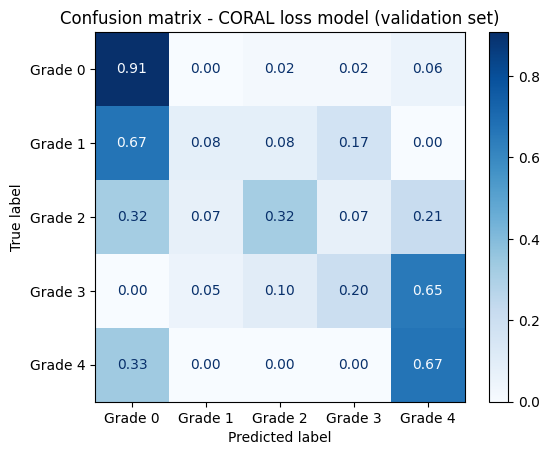

In [23]:
print("Training final CORAL model on full training set")

# Reset seeds for reproducibility on re-run
set_seed(SEED)
GEN.manual_seed(SEED)

EPOCHS = 50
BATCH_SIZE = 32

# CORAL importance weights (Cao et al. 2019, Eq.7)
N_CORAL = len(all_targets)
class_counts_coral = np.bincount(all_targets, minlength=5)
cum_pos_coral = np.cumsum(class_counts_coral[::-1])[::-1][1:]  # S_k for k=0..3
M_coral = np.maximum(cum_pos_coral, N_CORAL - cum_pos_coral)
sqrt_M_coral = np.sqrt(M_coral)
coral_importance = torch.tensor(
    sqrt_M_coral / sqrt_M_coral.max(), dtype=torch.float32, device=DEVICE
)
print(f"CORAL importance weights: {coral_importance.cpu().numpy()}")

final_loader = DataLoader(
    FolderDataset(all_paths, all_targets, train_transforms),
    batch_size=BATCH_SIZE, shuffle=True,
    worker_init_fn=worker_init_fn, num_workers=2,
    generator=GEN
)
val_loader  = DataLoader(val_data,  batch_size=BATCH_SIZE, shuffle=False,
                         worker_init_fn=worker_init_fn, num_workers=2, generator=GEN)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False,
                         worker_init_fn=worker_init_fn, num_workers=2, generator=GEN)

model_coral_final = MicroSENet(num_classes=5, use_coral=True, use_dla=False).to(DEVICE)
optimizer = torch.optim.AdamW(model_coral_final.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_auc, best_state, stale_epochs = 0.0, None, 0

for epoch in range(1, EPOCHS + 1):
    model_coral_final.train()
    train_loss = 0.0
    for x, y in final_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        levels = levels_from_labelbatch(y, num_classes=model_coral_final.num_classes).to(DEVICE)
        optimizer.zero_grad()
        logits = model_coral_final(x)
        loss = coral_loss(logits, levels, importance_weights=coral_importance)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(final_loader)

    model_coral_final.eval()
    val_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model_coral_final(x)
            levels = levels_from_labelbatch(y, num_classes=model_coral_final.num_classes).to(DEVICE)
            val_loss += coral_loss(logits, levels, importance_weights=coral_importance).item()

            probas = torch.sigmoid(logits)
            preds = proba_to_label(probas)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

            class_probs = torch.cat([
                1 - probas[:, :1],
                probas[:, :-1] - probas[:, 1:],
                probas[:, -1:],
            ], dim=1)
            all_probs.append(class_probs.cpu().numpy())
    val_loss /= len(val_loader)
    all_probs = np.concatenate(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')

    if auc > best_auc:
        best_auc = auc
        best_state = copy.deepcopy(model_coral_final.state_dict())
        stale_epochs = 0
    else:
        stale_epochs += 1

    scheduler.step()

    if epoch == 1 or epoch % 5 == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f"  Epoch {epoch:2d}/{EPOCHS} | LR: {lr_now:.2e} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | Acc: {acc:.4f} | QWK: {qwk:.4f} | AUC: {auc:.4f}")

    if stale_epochs >= 10:
        print(f"  Early stopping at epoch {epoch}")
        break

model_coral_final.load_state_dict(best_state)
model_coral_final.eval()

val_preds, val_labels, val_probs = [], [], []
with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model_coral_final(x)
        probas = torch.sigmoid(logits)
        preds = proba_to_label(probas)
        val_preds.extend(preds.cpu().numpy())
        val_labels.extend(y.cpu().numpy())

        class_probs = torch.cat([
            1 - probas[:, :1],
            probas[:, :-1] - probas[:, 1:],
            probas[:, -1:],
        ], dim=1)
        val_probs.append(class_probs.cpu().numpy())
val_probs = np.concatenate(val_probs)

print(f"\nValidation set results:")
print(f"  Macro F1:  {f1_score(val_labels, val_preds, average='macro'):.4f}")
print(f"  QWK:       {cohen_kappa_score(val_labels, val_preds, weights='quadratic'):.4f}")
print(f"  Accuracy:  {accuracy_score(val_labels, val_preds):.4f}")
print(f"  AUC:       {roc_auc_score(val_labels, val_probs, multi_class='ovr', average='macro'):.4f}")

cm = confusion_matrix(val_labels, val_preds, normalize='true')

print(f"\nPer-class metrics:")
for cls in range(5):
    recall = cm[cls, cls] / cm[cls].sum() if cm[cls].sum() > 0 else 0.0
    prec   = cm[:, cls][cls] / cm[:, cls].sum() if cm[:, cls].sum() > 0 else 0.0
    f1_c   = 2 * prec * recall / (prec + recall + 1e-8)
    print(f"  Grade {cls}: precision={prec:.3f} recall={recall:.3f} F1={f1_c:.3f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4'])
disp.plot(cmap=plt.cm.Blues, values_format='.2f')
plt.title("Confusion matrix - CORAL loss model (validation set)")
plt.show()

### CORAL loss model test set evaluation

In [ ]:
test_preds, test_labels, test_probs = [], [], []
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model_coral_final(x)
        probas = torch.sigmoid(logits)
        preds = proba_to_label(probas)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(y.cpu().numpy())

        class_probs = torch.cat([
            1 - probas[:, :1],
            probas[:, :-1] - probas[:, 1:],
            probas[:, -1:],
        ], dim=1)
        test_probs.append(class_probs.cpu().numpy())
test_probs = np.concatenate(test_probs)

print(f"Test set results:")
print(f"  Macro F1:  {f1_score(test_labels, test_preds, average='macro'):.4f}")
print(f"  QWK:       {cohen_kappa_score(test_labels, test_preds, weights='quadratic'):.4f}")
print(f"  Accuracy:  {accuracy_score(test_labels, test_preds):.4f}")
print(f"  AUC:       {roc_auc_score(test_labels, test_probs, multi_class='ovr', average='macro'):.4f}")

cm = confusion_matrix(test_labels, test_preds, normalize='true')

print(f"\nPer-class metrics:")
for cls in range(5):
    recall = cm[cls, cls] / cm[cls].sum() if cm[cls].sum() > 0 else 0.0
    prec   = cm[:, cls][cls] / cm[:, cls].sum() if cm[:, cls].sum() > 0 else 0.0
    f1_c   = 2 * prec * recall / (prec + recall + 1e-8)
    print(f"  Grade {cls}: precision={prec:.3f} recall={recall:.3f} F1={f1_c:.3f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4'])
disp.plot(cmap=plt.cm.Blues, values_format='.2f')
plt.title("Confusion Matrix - CORAL Loss (test set)")
plt.show()

## 8. Out-of-distribution evaluation

## 9. Explaining model predictions (GradCAM++)

## 10. Post-processing techniques

### Temperature scaling